# KG4Fun Splits Visualization
This notebook visualizes the difference between the **Inductive** and **Hybrid** splits for the KG4Fun benchmark, showing how the schemas and instances are partitioned.

In [1]:
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pandas as pd

os.chdir("..")

def load_json(path):
    with open(path, 'r') as f:
        return json.load(f)

DATASET = 'dataset1'
INDUCTIVE_PATH = f'data/raw/kg4fun/{DATASET}/splits/inductive'
HYBRID_PATH = f'data/raw/kg4fun/{DATASET}/splits/hybrid'
sns.set_theme(style="whitegrid")

## 1. Schema Graph Distribution
Let's analyze how the ontology (schema classes and relations) is assigned to Train, Val, and Test in both settings.

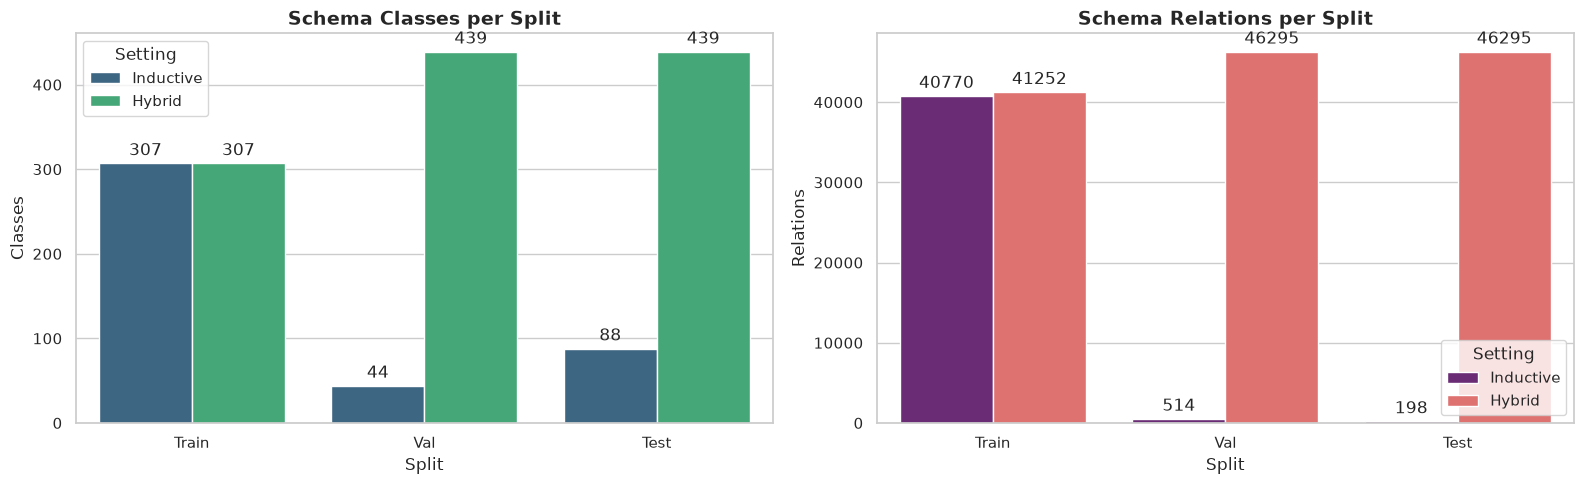

In [2]:
def get_schema_stats(split_path):
    stats = {}
    for split in ['train', 'val', 'test']:
        node_types_path = os.path.join(split_path, split, 'node_types.json')
        edge_types_path = os.path.join(split_path, split, 'edges', 'edge_types.json')
        if os.path.exists(node_types_path):
            nt = load_json(node_types_path)
            et = load_json(edge_types_path)
            stats[split] = {'Classes': len(nt), 'Relations': len(et)}
        else:
            stats[split] = {'Classes': 0, 'Relations': 0}
    return stats

ind_schema = get_schema_stats(INDUCTIVE_PATH)
hyb_schema = get_schema_stats(HYBRID_PATH)

df_schema = pd.DataFrame({
    'Split': ['Train', 'Val', 'Test', 'Train', 'Val', 'Test'],
    'Setting': ['Inductive']*3 + ['Hybrid']*3,
    'Classes': [ind_schema['train']['Classes'], ind_schema['val']['Classes'], ind_schema['test']['Classes'],
                hyb_schema['train']['Classes'], hyb_schema['val']['Classes'], hyb_schema['test']['Classes']],
    'Relations': [ind_schema['train']['Relations'], ind_schema['val']['Relations'], ind_schema['test']['Relations'],
                  hyb_schema['train']['Relations'], hyb_schema['val']['Relations'], hyb_schema['test']['Relations']]
})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax1 = sns.barplot(data=df_schema, x='Split', y='Classes', hue='Setting', palette='viridis', ax=axes[0])
axes[0].set_title('Schema Classes per Split', fontsize=14, weight='bold')
for i in ax1.containers:
    ax1.bar_label(i, padding=3)

ax2 = sns.barplot(data=df_schema, x='Split', y='Relations', hue='Setting', palette='magma', ax=axes[1])
axes[1].set_title('Schema Relations per Split', fontsize=14, weight='bold')
for i in ax2.containers:
    ax2.bar_label(i, padding=3)

plt.tight_layout()
plt.savefig('reports/figures/schema_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

**Observation**: In the **Inductive** setting, the schema classes are strictly partitioned across all three splits (they are disjoint). However, in the **Hybrid** setting, while Train receives a subset (simulating the base ontology), Val and Test receive the **entire global schema** to simulate encountering new concepts over time.

## 2. Instance Graph Distribution
Now we analyze the actual input graph components (entity instances and edges/facts) across the splits.

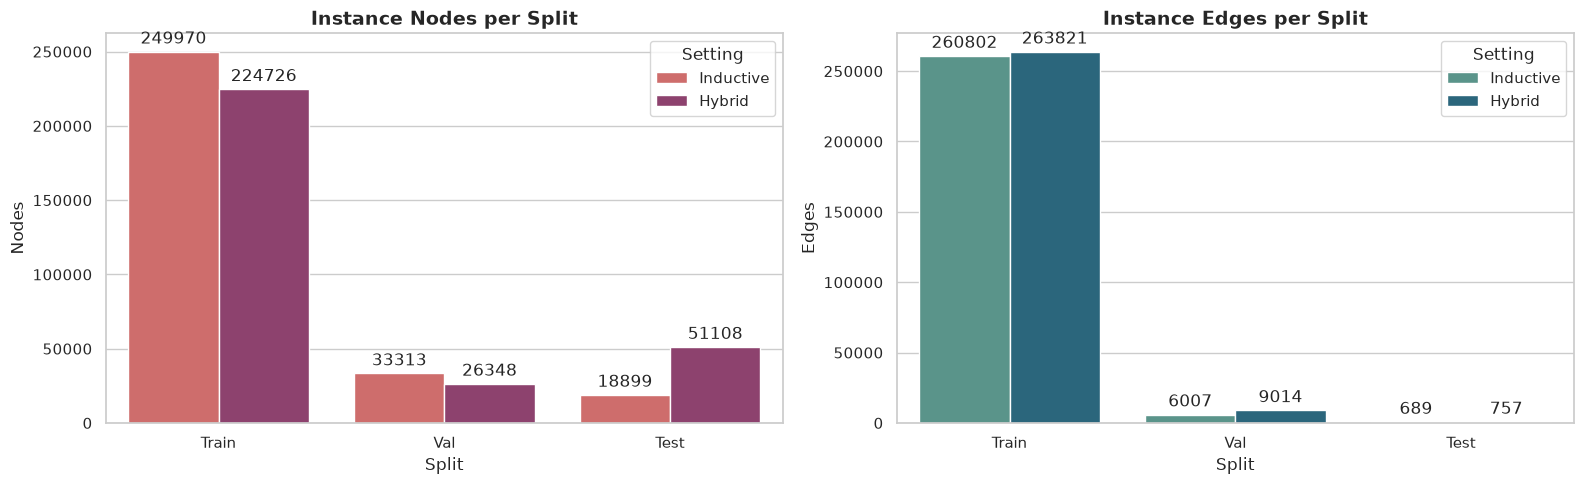

In [3]:
def get_instance_stats(split_path):
    stats = {}
    for split in ['train', 'val', 'test']:
        nodes_path = os.path.join(split_path, split, 'nodes.json')
        edges_path = os.path.join(split_path, split, 'edges', 'partition', 'part_0.json')
        if os.path.exists(nodes_path):
            n = load_json(nodes_path)
            e = load_json(edges_path)
            stats[split] = {'Nodes': len(n), 'Edges': len(e)}
        else:
            stats[split] = {'Nodes': 0, 'Edges': 0}
    return stats

ind_inst = get_instance_stats(INDUCTIVE_PATH)
hyb_inst = get_instance_stats(HYBRID_PATH)

df_inst = pd.DataFrame({
    'Split': ['Train', 'Val', 'Test', 'Train', 'Val', 'Test'],
    'Setting': ['Inductive']*3 + ['Hybrid']*3,
    'Nodes': [ind_inst['train']['Nodes'], ind_inst['val']['Nodes'], ind_inst['test']['Nodes'],
              hyb_inst['train']['Nodes'], hyb_inst['val']['Nodes'], hyb_inst['test']['Nodes']],
    'Edges': [ind_inst['train']['Edges'], ind_inst['val']['Edges'], ind_inst['test']['Edges'],
              hyb_inst['train']['Edges'], hyb_inst['val']['Edges'], hyb_inst['test']['Edges']]
})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=df_inst, x='Split', y='Nodes', hue='Setting', ax=axes[0], palette='flare')
axes[0].set_title('Instance Nodes per Split', fontsize=14, weight='bold')
for i in axes[0].containers:
    axes[0].bar_label(i, padding=3)

sns.barplot(data=df_inst, x='Split', y='Edges', hue='Setting', ax=axes[1], palette='crest')
axes[1].set_title('Instance Edges per Split', fontsize=14, weight='bold')
for i in axes[1].containers:
    axes[1].bar_label(i, padding=3)
plt.tight_layout()
plt.savefig('reports/figures/instance_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

**Observation**: The instance graphs scale differently depending on how the schema shapes the BFS traversal. In **Hybrid**, the Train split BFS is strictly constrained to traverse *only* nodes belonging to the train schema classes, resulting in a heavily dense core of 'base' nodes, leaving the rest of the vast network (and new concepts) for Val and Test.

## 3. Schema Topology Visualization
We can peek at a sampled sub-graph of the Schema to visualize how these conceptual islands take shape.

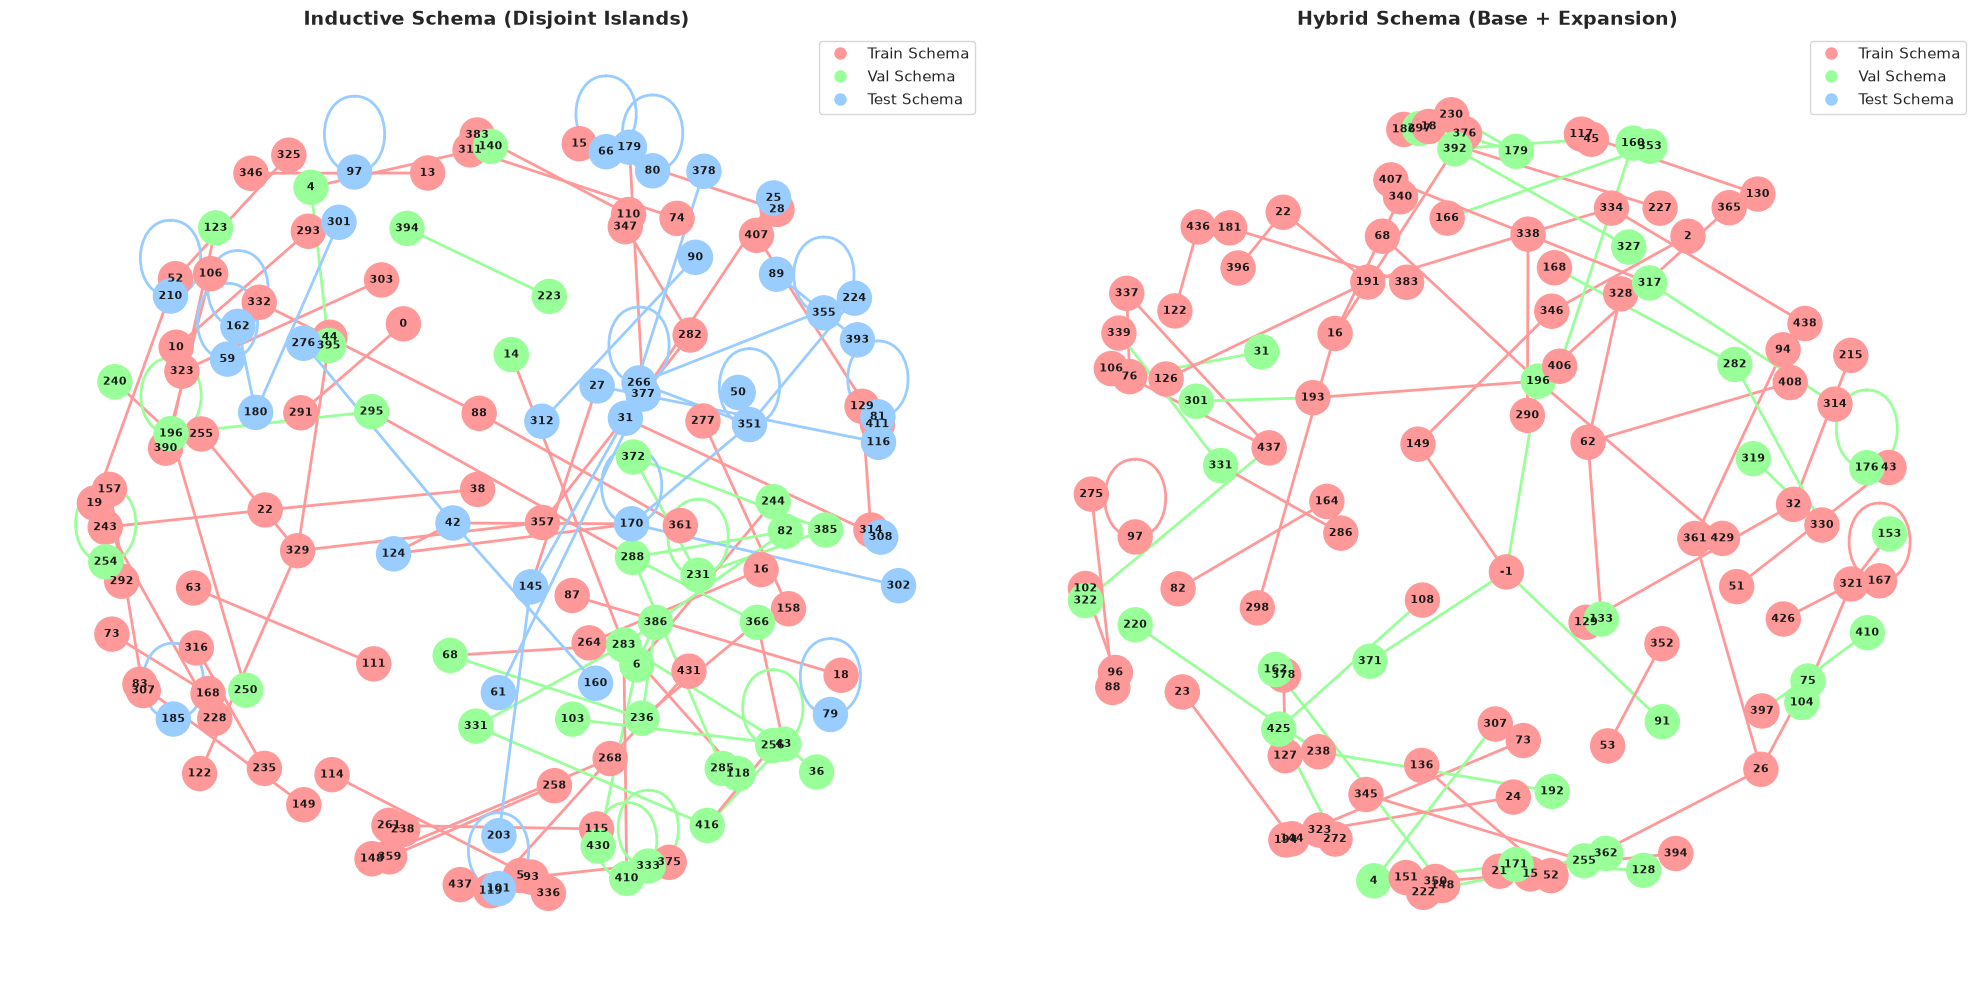

In [4]:
def draw_unified_schema(split_path, ax, title):
    G = nx.Graph()
    
    # Load edge types for all splits
    edges_by_split = {}
    for split in ['train', 'val', 'test']:
        et_path = os.path.join(split_path, split, 'edges', 'edge_types.json')
        if os.path.exists(et_path):
            edges_by_split[split] = load_json(et_path)
        else:
            edges_by_split[split] = []
            
    # Priority for source: train > val > test
    edge_sources = {}
    node_sources = {}
    
    for split in ['train', 'val', 'test']:
        for et in edges_by_split[split]:
            edge = (et['head_cls'], et['tail_cls'])
            if edge not in edge_sources:
                edge_sources[edge] = split
            if edge[0] not in node_sources:
                node_sources[edge[0]] = split
            if edge[1] not in node_sources:
                node_sources[edge[1]] = split
                
    # Sample a connected subgraph to make it look nice
    sample_edges = []
    import random
    random.seed(42)
    for split in ['train', 'val', 'test']:
        split_edges = [e for e, s in edge_sources.items() if s == split]
        sample_edges.extend(random.sample(split_edges, min(40, len(split_edges))))
        
    for u, v in sample_edges:
        G.add_edge(u, v)
        
    # Colors
    color_map = {'train': '#ff9999', 'val': '#99ff99', 'test': '#99ccff'}
    
    node_colors = [color_map[node_sources.get(node, 'train')] for node in G.nodes()]
    edge_colors = [color_map[edge_sources.get(edge, 'train')] for edge in G.edges()]
    
    pos = nx.spring_layout(G, seed=42, k=0.5)
    nx.draw(G, pos, ax=ax, with_labels=True, node_color=node_colors, 
            node_size=600, font_size=8, font_weight='bold', edge_color=edge_colors, width=2.0)
    
    # Custom legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Train Schema', markerfacecolor='#ff9999', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Val Schema', markerfacecolor='#99ff99', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Test Schema', markerfacecolor='#99ccff', markersize=10)
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    ax.set_title(title, fontsize=14, weight='bold')

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
draw_unified_schema(INDUCTIVE_PATH, axes[0], 'Inductive Schema (Disjoint Islands)')
draw_unified_schema(HYBRID_PATH, axes[1], 'Hybrid Schema (Base + Expansion)')
plt.tight_layout()
plt.savefig('reports/figures/schema_unified.png', bbox_inches='tight', dpi=300)
plt.show()